In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# 设置绘图字体（解决中文显示问题）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

### 1. 数据准备 (Dataset)
# 请确保 Concrete_Data_Yeh.csv 路径正确
file_path = "D:/入学材料/研一/神经网络及其应用/Assignment1/Concrete_Data_Yeh.csv"
df = pd.read_csv(file_path)

# 按照作业要求：使用全部 8 个输入变量
X = df.iloc[:, :8]
y = df.iloc[:, 8:]

# 优化点：开启 shuffle=True 保证数据分布均匀
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

# 标准化特征
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 转换为 PyTorch 张量
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)

In [2]:
### 2. 神经网络构建 (Neural Network Construction)
class ConcreteStrengthNet(nn.Module):
    def __init__(self, input_dim):
        super(ConcreteStrengthNet, self).__init__()
        # 结构优化：增加层深与宽度，加入 BatchNorm 和 Dropout
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)


# 实例化模型
model = ConcreteStrengthNet(input_dim=8)


In [3]:
### 3. 模型训练 (Model Training)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)  # 初始学习率略微调高
# 学习率调度器：每 400 轮将学习率减半
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=400, gamma=0.5)

epochs = 1500  # 增加迭代次数以保证充分收敛
loss_history = []

print("\n--- 开始优化后的模型训练 ---")
for epoch in range(epochs):
    model.train()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()  # 更新学习率

    loss_history.append(loss.item())

    if (epoch + 1) % 100 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}, LR: {current_lr}')



--- 开始优化后的模型训练 ---
Epoch [100/1500], Loss: 131.9469, LR: 0.01
Epoch [200/1500], Loss: 114.9148, LR: 0.01
Epoch [300/1500], Loss: 107.5202, LR: 0.01
Epoch [400/1500], Loss: 104.8039, LR: 0.005
Epoch [500/1500], Loss: 104.5814, LR: 0.005
Epoch [600/1500], Loss: 97.7629, LR: 0.005
Epoch [700/1500], Loss: 79.0747, LR: 0.005
Epoch [800/1500], Loss: 60.5951, LR: 0.0025
Epoch [900/1500], Loss: 51.4853, LR: 0.0025
Epoch [1000/1500], Loss: 54.9699, LR: 0.0025
Epoch [1100/1500], Loss: 44.3669, LR: 0.0025
Epoch [1200/1500], Loss: 48.0036, LR: 0.00125
Epoch [1300/1500], Loss: 42.4165, LR: 0.00125
Epoch [1400/1500], Loss: 36.3595, LR: 0.00125
Epoch [1500/1500], Loss: 44.9447, LR: 0.00125


In [4]:
### 4. 模型测试与评估 (Evaluation)
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    y_pred_numpy = y_pred_tensor.numpy()
    y_true_numpy = y_test_tensor.numpy()

    mse = mean_squared_error(y_true_numpy, y_pred_numpy)
    r2 = r2_score(y_true_numpy, y_pred_numpy)
    print(f'\n测试集均方误差 (MSE): {mse:.4f}')
    print(f'测试集决定系数 (R2 Score): {r2:.4f}')


测试集均方误差 (MSE): 45.2421
测试集决定系数 (R2 Score): 0.8244


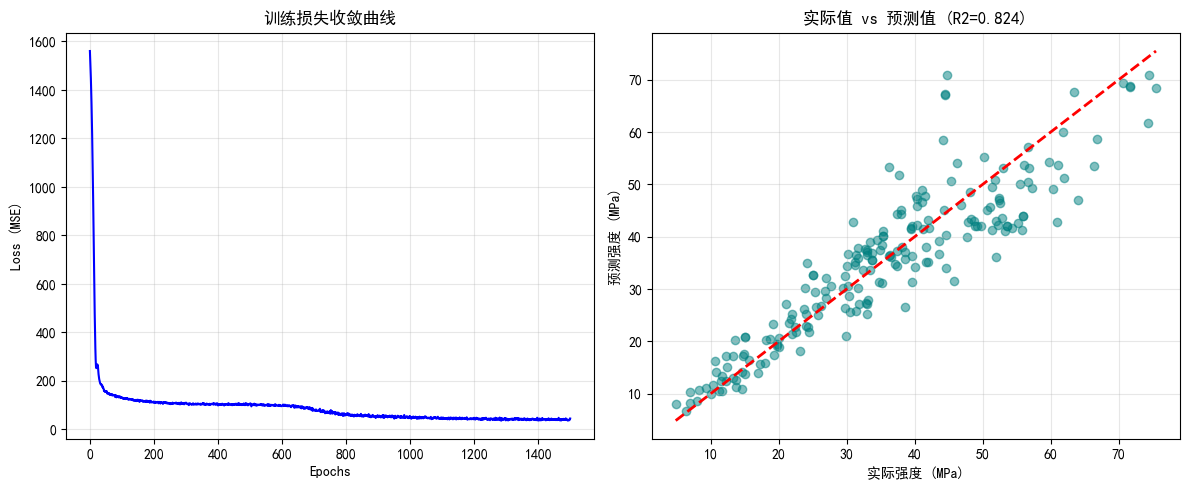

In [5]:
### 5. 可视化 (Visualization)
plt.figure(figsize=(12, 5))

# 图 1：Loss 下降曲线
plt.subplot(1, 2, 1)
plt.plot(loss_history, color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('训练损失收敛曲线')
plt.grid(True, alpha=0.3)

# 图 2：预测对比图
plt.subplot(1, 2, 2)
plt.scatter(y_true_numpy, y_pred_numpy, alpha=0.5, color='teal')
plt.plot([y_true_numpy.min(), y_true_numpy.max()], [y_true_numpy.min(), y_true_numpy.max()], 'r--', lw=2)
plt.xlabel('实际强度 (MPa)')
plt.ylabel('预测强度 (MPa)')
plt.title(f'实际值 vs 预测值 (R2={r2:.3f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()